In [43]:
import numpy as np
import matplotlib.pyplot as plt
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

In [44]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, bathymetry: np.ndarray, uh_initial: np.ndarray | None = None, vh_initial: np.ndarray | None = None, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        self.bathymetry = bathymetry
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid, n_threads = 1)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        if uh_initial is None:
            uh_initial = np.zeros(grid)
        if vh_initial is None:
            vh_initial = np.zeros(grid)
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h'] - self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

$\textbf{Jak kształt dna rzeki wpływa na rozchodzenie się fali?}$

Celem projektu jest zbadanie przepływu fali przez koryto rzeki, dla różnego ukszatłtowania dna. Rozważono różne kształty: paraboliczne, Gaussowskie, trapezoidalne i trójkątne. Ustalono jednakową maksymalną głębokość dla dowolnego dna, 1.1 m, szerokość rzeki 20 m, długość rzeki 30 m. Jako model fali przyjęto dwuwymiarowego Gaussa o wymiarach odchylenia (3, 2.5) m i wysokości 20 cm, wraz z prędkością początkową 10 cm/s.

Kroki siatki ustalwiono jako $\Delta x$ = $\Delta y$ = 10 cm. Ustawiono krok czasowy $\Delta t$ =  4 ms, z całkowitym czasem symulacji równym 5 s.

In [45]:
# parametry symulacji
Lx = 30.0  
Ly = 20.0
dx = 0.1
dy = dx

Nx = int(Lx / dx)
Ny = int(Ly / dy)
grid = (Nx, Ny)
max_b = 1
xmin = 0
xmax = Lx
ymin = -Ly/2
ymax = Ly/2
dt = 0.004
t = 5

# definicje batymerii
bathymetries = {}
y = np.linspace(ymin, ymax, Ny)
x = np.linspace(xmin, xmax, Nx)
X, Y = np.meshgrid(x, y, indexing='ij')

gauss = max_b * np.exp(-(y/6)**2) + 0.1
bathymetries["gaussian"] = np.tile(gauss, (Nx, 1))

parabola = max_b * (1 - (2 * np.abs(y) / Ly)**2) + 0.1
bathymetries["parabolic"] = np.tile(parabola, (Nx, 1))

trapezius = max_b * (1 - np.maximum(0, (np.abs(y) - 5) / (10 - 5)))  + 0.1
bathymetries["trapezoid"] = np.tile(trapezius, (Nx, 1))

triangle = max_b * (1 - 2 * np.abs(y) / Ly) + 0.1
bathymetries["triangular"] = np.tile(triangle, (Nx, 1))



In [ ]:
# parametry fali początkowej
wave_amp = .2
wave_sigma_x = 3
wave_sigma_y = 2.5
wave_uh_amp = 0.01
wave_uh_sigma_x = 3
wave_uh_sigma_y = 2.5

outfreq = 10

outputs = {}
for (name, bathymetry) in bathymetries.items():
    print(name)
    h_initial = np.copy(bathymetry)
    wave = wave_amp * np.exp(
    - (X / wave_sigma_x)**2
    - (Y / wave_sigma_y)**2
    )

    h_initial += wave
    uh_initial = np.zeros(grid)
    wave_uh = wave_uh_amp * np.exp(
        - (X / wave_uh_sigma_x)**2
        - (Y / wave_uh_sigma_y)**2
    )
    uh_initial += wave_uh

    output = ShallowWaterEquationsIntegrator(
        h_initial=h_initial, bathymetry=bathymetry, uh_initial = uh_initial
    )(
        nt=int(t/dt), g=10, dt_over_dxy=(dt/dx, dt/dy), outfreq=outfreq
    )
    outputs[name] = output


gaussian


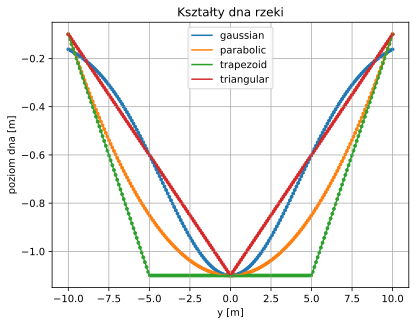

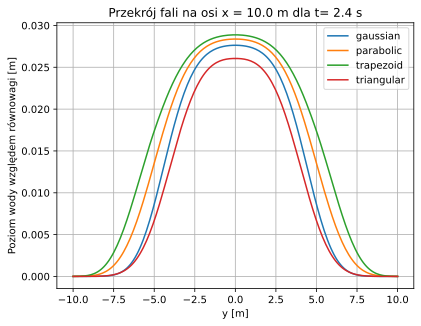

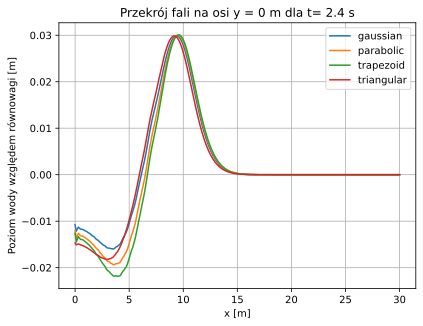

In [ ]:
plt.figure()
for name in bathymetries.keys():
    plt.plot(y, -bathymetries[name][0], label=name)
    plt.scatter(y, -bathymetries[name][0], s = 8)
plt.legend()
plt.grid()
plt.title("Kształty dna rzeki")
plt.ylabel("poziom dna [m]")
plt.xlabel("y [m]")
show_plot("dna.pdf")



    
for (name, output) in outputs.items():
    plt.plot(y, output['h'][60][100, :] - bathymetries[name][1, :], label = name)
plt.legend()
plt.grid()
plt.xlabel("y [m]")
plt.ylabel("Poziom wody względem równowagi [m]")
plt.title(f"Przekrój fali na osi x = {100*dx} m dla t= {60*dt*outfreq} s")
show_plot("przekrojey.pdf")



for (name, output) in outputs.items():
    plt.plot(x, output['h'][60][:, Ny//2] - bathymetries[name][:, Ny//2], label = name)
plt.legend()
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("Poziom wody względem równowagi [m]")
plt.title(f"Przekrój fali na osi y = {0} m dla t= {60*dt*outfreq} s")
show_plot("przekrojex.pdf")

Teoria równań płytkiej wody potwierdza, że prędkość fali rośnie wraz z głębokością ($c = \sqrt{gH}$), dlatego szerokie dno trapezoidalne, utrzymujące maksymalną głębokość na największej powierzchni, sprzyja najwyższej prędkości propagacji w centrum rzeki.

Różnica w przekroju na osi x = 0 jest widoczna, zgodnie z oczekiwaniami amplituda fali przy dnie trapezoidalnym jest największa, a przy dnie trójkątnym - najmniejsza, kształty fali dla dna parabolicznego i Gaussowskiego mieszczą się pomiędzy nimi.

Obserwując przekroje fal na osi y = 0 (wzdłuż środka rzeki), można zauważyć najwyższą prędkość (co można wywnioskować z położenia) fali dla dna trapezoidalnego i najmniejszą dla dna trójkątnego, co jest analogiczne dla rozważań dla przekroju wzdłuż osi x. Szerokości poprzeczne fal również zależą od kształtu brzegu. Najszersza poprzeczna szerokość fali dla dna trapezoidalnego wynika z równomiernej prędkości wzdłuż szerokiej, płaskiej strefy, prowadząc do najmniejszego skupienia energii w centralnym punkcie rzeki.



$\textbf{Pola prędkości}$

In [ ]:
def plot(frame, *, zlim=(-.25, .25)):
    cases = bathymetries.keys()
    fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "3d"}, figsize=(16, 12), constrained_layout=True)
    
    for ax, case in zip(axes.flatten(), cases):
        psi = outputs[case]['h'][frame]
        bathymetry = bathymetries[case]
        
        ax.plot_wireframe(X, Y, psi - bathymetry, color='blue', linewidth=.5)
        
        ax.set(zlim=zlim, proj_type='ortho', title=f"Dno: {case}, t = {frame*dt*outfreq:.2f} [s]", zlabel=r"wysokość względem poziomu referencyjnego [m]")
        
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.fill = False
            axis.pane.set_edgecolor('black')
            axis.pane.set_alpha(1)
            
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        
        contour = ax.contourf(X, Y, bathymetry, zdir='z', offset=zlim[0])
        
        cbar = plt.colorbar(
            contour,
            ax=ax,
            pad=.1, aspect=10, fraction=.02, label='batymetria', 
            location='left'
        )
        cbar.ax.invert_yaxis()
    return fig
#show_anim(plot, range(len(outputs["parabolic"]['h'])))

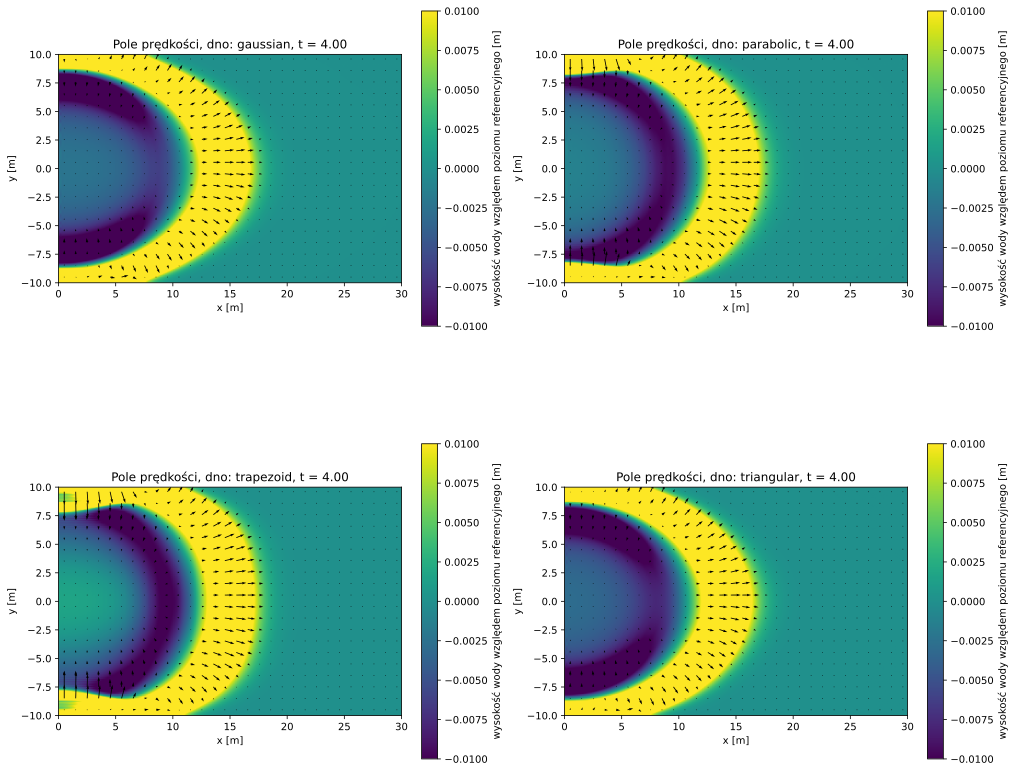

In [ ]:
def plot_quiver(frame, *, scale=3, stride=10):
    cases = bathymetries.keys()
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

    for ax, case in zip(axes.flatten(), cases):
        psi = outputs[case]['h'][frame]
        u = outputs[case]['uh'][frame]
        v = outputs[case]['vh'][frame]
        bathymetry = bathymetries[case]

        im = ax.imshow(
            (psi - bathymetry).T, 
            origin='lower', 
            cmap='viridis', 
            vmin=-0.01, vmax=0.01,
            extent = [xmin, xmax, ymin, ymax]
        )
        
        plt.colorbar(im, ax=ax, label="wysokość wody względem poziomu referencyjnego [m]", fraction=0.046, pad=0.04)

        ax.quiver(
            X[::stride, ::stride] + 0.5,
            Y[::stride, ::stride] + 0.5,
            u[::stride, ::stride],
            v[::stride, ::stride],
            scale=scale
        )
        ax.set_title(f"Pole prędkości, dno: {case}, t = {frame*dt*outfreq:.2f} s")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_aspect('equal')

    return fig

plot_quiver(frame=int(4/dt/outfreq))
show_plot("quiver.pdf")
#show_anim(plot_quiver, range(len(outputs["parabolic"]['h'])))d

Prędkość w poprzek rzeki zależy od poziomu dna, dla dna trapezoidalnego dno jest najgłębsze (w porównaniu do innych den) - można zaobserwować najszybszą propagację fali i najbardziej płaski kształt czoła fali. Dla dna parabolicznego widać minimalnie niższą prędkość poprzeczną i podobny (bardziej zaokrąglony) kształt czoła fali. Dla den o kształcie Gaussowkim i trójkątnym kształty czoła fali są niemalże identyczne - najwolniejsze prędkości poprzeczne i podobne, zaokrąglone czoła fali.





$\textbf{Test zbieżności}$

Test zbieżności przeprowadzono tylko dla kształtu parabolicznego ze względu na wysoki czas symulacji.

In [ ]:
dx2 = dx * 2
dy2 = dy * 2
dt2 = dt * 2

Nx2 = int(Lx / dx2)
Ny2 = int(Ly / dy2)
grid2 = (Nx2, Ny2)

outfreq2 = int(outfreq / 2)

y2 = np.linspace(ymin, ymax, Ny2)
x2 = np.linspace(xmin, xmax, Nx2)
X2, Y2 = np.meshgrid(x2, y2, indexing='ij')


parabola2 = max_b * (1 - (2 * np.abs(y2) / Ly)**2) + 0.1
bathymetry2 = np.tile(parabola2, (Nx2, 1))

h_initial2 = np.copy(bathymetry2)
wave2 = wave_amp * np.exp(
    - (X2 / wave_sigma_x)**2
    - (Y2 / wave_sigma_y)**2
)
h_initial2 += wave2

uh_initial2 = np.zeros(grid2)
wave_uh2 = wave_uh_amp * np.exp(
    - (X2 / wave_uh_sigma_x)**2
    - (Y2 / wave_uh_sigma_y)**2
)
uh_initial2 += wave_uh2

output2 = ShallowWaterEquationsIntegrator(
    h_initial=h_initial2, bathymetry=bathymetry2, uh_initial=uh_initial2
)(
    nt=int(t/dt2), g=10, dt_over_dxy=(dt2/dx2, dt2/dy2), outfreq=outfreq2
)
    

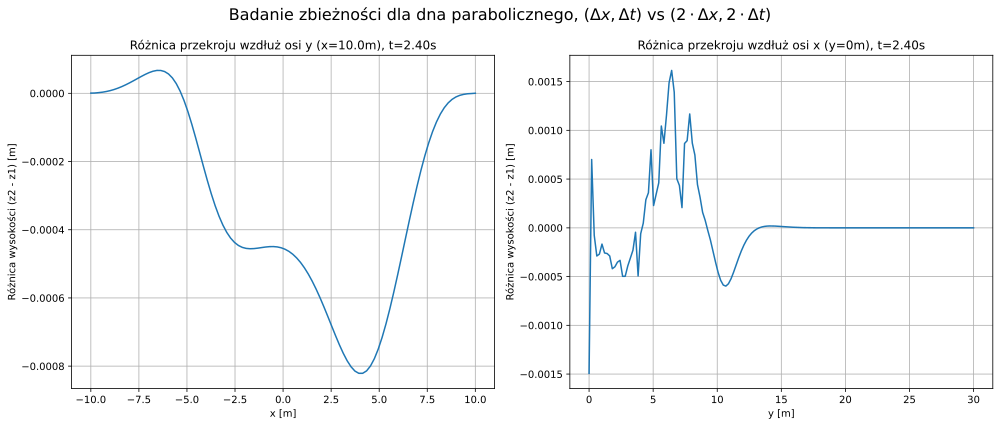

In [ ]:
z1 = outputs["parabolic"]['h'][60][100, :] - bathymetries["parabolic"][1, :]
z2 = output2['h'][60][50, :] - bathymetry2[1, :]
z1 = z1[::2]
z_diff = z2 - z1

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

plt.plot(y2, z_diff)
plt.title(f"Różnica przekroju wzdłuż osi y (x={100*dx}m), t={120*dt*outfreq2:.2f}s")
plt.xlabel("x [m]")
plt.ylabel(r"Różnica wysokości (z2 - z1) [m]")
plt.grid()

plt.subplot(1, 2, 2)

z3 = outputs["parabolic"]['h'][60][:, Ny//2] - bathymetries["parabolic"][:, Ny//2]
z4 = output2['h'][60][:, Ny2//2] - bathymetry2[:, Ny2//2]
z3 = z3[::2]
z_diff2 = z4 - z3
plt.plot(x2, z_diff2)
plt.title(f"Różnica przekroju wzdłuż osi x (y=0m), t={60*dt*outfreq:.2f}s")
plt.xlabel("y [m]")
plt.ylabel(r"Różnica wysokości (z2 - z1) [m]")
plt.grid()

plt.suptitle(rf"Badanie zbieżności dla dna parabolicznego, ($\Delta x, \Delta t$) vs ($2\cdot \Delta x, 2\cdot \Delta t$)", fontsize=16)
plt.tight_layout()
show_plot(f"convergence.pdf")

Parametry symulacji są dobrane z dużym zakresem bezpieczeństwa, pomimo zwiększenia kroku czasowego i kroków siatki dwukrotnie różnice między poziomami fali są zauważalne, lecz niewielkie - rzędu milimetrów (przy 20 cm wysokości fali początkowej).